# Práctica 3 — ENDIREH 2021: Arquitectura, Preprocesamiento y EDA

**Integrantes:** Erick Luis Juárez   
                 Julio Alejandro Herrera Avalos   
                 Luis Mario Solares Ramos  
                 Cesar Candelario Fuentes Anica

Framework utilizado: **polars**.

## Paso 3: Selección del Framework
Se elige polars por su buen rendimiento en datasets medianos (~110 mil filas) en
una sola máquina, con sintaxis cercana a pandas. No se requiere PySpark (pensado
para Big Data distribuido).

## Paso 4: Carga de los Datos Crudos

In [15]:
import sys
from pathlib import Path
import polars as pl
import numpy as np

#Configuramos  ruta raíz para importar config/ y src/
RAIZ_PROYECTO = Path("..").resolve()
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.append(str(RAIZ_PROYECTO))

# Importar rutas
from config.rutas import (
    RUTA_DATA_RAW,
    RUTA_DATA_PROCESSED,
    RUTA_DATA_INPUT_MODEL,
    ARCHIVO_ENDIREH_RAW,
    ARCHIVO_ENDIREH_PROCESSED
)

#Importamos funciones limpias desde tu carpeta src/
from src.cleaning.preprocessing import (
    eliminar_duplicados,
    limpiar_valores_centinela,
    convertir_tipos_datos,
    imputar_datos,
)
from src.visualization.eda import (
    obtener_resumen_nulos,
    calcular_medidas_localizacion,
    calcular_medidas_variabilidad
)

#Cargamos dataset crudo con Polars
lf_crudo = pl.scan_csv(RUTA_DATA_RAW / ARCHIVO_ENDIREH_RAW)
df_crudo = lf_crudo.collect()

print(f"Dimensiones del dataset crudo: {df_crudo.shape}")
df_crudo.head()

Dimensiones del dataset crudo: (110127, 24)


cve_entidad,nom_entidad,cve_municipio,nom_municipio,edad_primer_union,num_hijos,nivel_escolaridad,estado_civil_id,estado_civil_desc,estrato_socioeconomico,pareja_trabaja_id,pareja_trabaja_desc,ingreso_pareja,dinero_propio_id,dinero_propio_desc,apoyo_gobierno_id,apoyo_gobierno_desc,tiene_ahorros_id,tiene_ahorros_desc,propietaria_vivienda_id,propietaria_vivienda_desc,sufrio_violencia_pareja,factor_expansion,anio_encuesta
i64,str,i64,str,f64,f64,str,i64,str,i64,i64,str,f64,i64,str,i64,str,i64,str,i64,str,i64,i64,i64
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3.0,"""A1""",5,"""Casada""",4,1,"""Sí""",10000.0,1,"""Sí""",2,"""No""",2,"""No""",1,"""Sí""",0,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3.0,"""A1""",5,"""Casada""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",1,"""Sí""",1,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",13.0,3.0,"""B2""",4,"""Viuda""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",2,"""No""",0,227,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,null,"""C1""",6,"""Soltera""",4,1,"""Sí""",8500.0,1,"""Sí""",2,"""No""",1,"""Sí""",1,"""Sí""",0,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",20.0,3.0,"""B1""",2,"""Separada""",2,1,"""Sí""",400.0,1,"""Sí""",2,"""No""",2,"""No""",1,"""Sí""",1,155,2021


## Preprocesamiento de Datos
Usamos las funciones de `src/cleaning/preprocessing.py` para limpiar duplicados, valores centinela (como 98, 99 o 999998), corregir el tipado e imputar valores faltantes

## Paso 5: EDA y Preprocesamiento

### 5.1 Duplicados
Se eliminan filas exactamente duplicadas 

In [16]:
#Conteo de duplicados exactos
n_antes = df_crudo.shape[0]
n_duplicados = df_crudo.is_duplicated().sum()
print(f"Filas totales: {n_antes}")
print(f"Filas duplicadas (exactas): {n_duplicados} ({100*n_duplicados/n_antes:.1f}%)")

#Eliminamos las filas duplicadas
df_sin_dup = df_crudo.unique(keep="first")
print(f"Filas después de eliminar duplicados: {df_sin_dup.shape[0]}")

Filas totales: 110127
Filas duplicadas (exactas): 7882 (7.2%)
Filas después de eliminar duplicados: 105753


### 5.2 Códigos especiales / valores centinela
El INEGI codifica no aplica con números que parecen datos válidos.
Se revisan los valores extremos antes de calcular cualquier estadística.

In [17]:
#Aplicamos la limpieza de valores centinela usando la función de src/cleaning/preprocessing.py
n_implausibles = df_sin_dup.filter(
    (pl.col("edad_primer_union") < 12) & pl.col("edad_primer_union").is_not_null()
    & ~pl.col("edad_primer_union").is_in([98, 99])
).shape[0]
print(f"Edades implausibles (<12, distintas de 98/99) recodificadas a nulo: {n_implausibles}")

df_centinela = limpiar_valores_centinela(df_sin_dup)

print("edad_primer_union - mínimo tras limpiar:", df_centinela["edad_primer_union"].min())
print("edad_primer_union - máximo tras limpiar:", df_centinela["edad_primer_union"].max())
print("ingreso_pareja - máximo tras limpiar:", df_centinela["ingreso_pareja"].max())

Edades implausibles (<12, distintas de 98/99) recodificadas a nulo: 15877
edad_primer_union - mínimo tras limpiar: 12.0
edad_primer_union - máximo tras limpiar: 76.0
ingreso_pareja - máximo tras limpiar: 800000.0


**Hallazgo:** en `edad_primer_union`, los valores más frecuentes en el extremo
alto son **98** (656 casos) y **99** (227 casos). Esto es raro porque nadie tiene
98 o 99 años en su primera unión de pareja — es físicamente imposible en el
contexto de la encuesta. En `ingreso_pareja` pasa lo mismo con **999997, 999998
y 999999** (más de 4,000 casos): nadie gana casi un millón de pesos exacto, ese
patrón "redondo" es la firma típica de un código especial.

Ambos son los códigos que usa el INEGI para "no especificado" / "no sabe" — no
son datos reales. Si no los detectamos y calculamos la media directamente, estos
valores inflan el promedio de forma artificial (de hecho, al calcularla sin
limpiar esto, la media de `edad_primer_union` salía en 13 años, un número
igual de imposible — así fue como nos dimos cuenta del problema).

**Decisión:** recodificar estos valores como nulos (`None`) antes de cualquier
cálculo, en vez de tratarlos como datos válidos.

Ademas, se detectaron **15,877** registros con edades entre 1 y 11 años,
también físicamente implausibles para una primera unión de pareja, aunque no
correspondan a los códigos centinela 98/99. Siguiendo el criterio mínimo de
nupcialidad usado en estudios de la ENDIREH, también se recodificaron como
nulos.

### 5.3 Conversión de tipos de datos
Columnas de códigos (`cve_entidad`, `*_id`) se convierten a categóricas;
`nivel_escolaridad` a categórica ordinal (A1 < ... < C2); `sufrio_violencia_pareja`
a booleana.

In [18]:
#Convertimos los tipos de datos usando la función de src/cleaning/preprocessing.py
df_tipos = convertir_tipos_datos(df_centinela)
df_tipos.schema

Schema([('cve_entidad', Categorical(ordering='physical')),
        ('nom_entidad', Categorical(ordering='physical')),
        ('cve_municipio', Categorical(ordering='physical')),
        ('nom_municipio', Categorical(ordering='physical')),
        ('edad_primer_union', Float64),
        ('num_hijos', Float64),
        ('nivel_escolaridad',
         Enum(categories=['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])),
        ('estado_civil_id', Categorical(ordering='physical')),
        ('estado_civil_desc', Categorical(ordering='physical')),
        ('estrato_socioeconomico', Int64),
        ('pareja_trabaja_id', Categorical(ordering='physical')),
        ('pareja_trabaja_desc', String),
        ('ingreso_pareja', Float64),
        ('dinero_propio_id', Categorical(ordering='physical')),
        ('dinero_propio_desc', String),
        ('apoyo_gobierno_id', Categorical(ordering='physical')),
        ('apoyo_gobierno_desc', String),
        ('tiene_ahorros_id', Categorical(ordering='physical')),
     

### 5.4 Valores nulos e imputación
Se revisa el patrón de cada variable antes de imputar

In [19]:
#Realizamos el conteo global de nulos por columna usando la función de src/visualization/eda.py
resumen_nulos = obtener_resumen_nulos(df_tipos)
resumen_nulos

columna,nulos,pct_nulos
str,i64,f64
"""edad_primer_union""",97968,92.6
"""ingreso_pareja""",60923,57.6
"""num_hijos""",19231,18.2


In [20]:
#Verificamos la  condicional: nulos en ingreso vs situación laboral de la pareja
print(df_tipos.group_by("pareja_trabaja_desc").agg([
    pl.len().alias("total"),
    pl.col("ingreso_pareja").null_count().alias("nulos_ingreso_pareja"),
]))

shape: (2, 3)
┌─────────────────────┬───────┬──────────────────────┐
│ pareja_trabaja_desc ┆ total ┆ nulos_ingreso_pareja │
│ ---                 ┆ ---   ┆ ---                  │
│ str                 ┆ u32   ┆ u32                  │
╞═════════════════════╪═══════╪══════════════════════╡
│ Sí                  ┆ 48859 ┆ 4029                 │
│ No                  ┆ 56894 ┆ 56894                │
└─────────────────────┴───────┴──────────────────────┘


**Hallazgo:** al cruzar los nulos de `ingreso_pareja` contra `pareja_trabaja_desc`,
coinciden casi exactamente con las mujeres cuya pareja **no trabaja**. Esto es
importante porque nos dice que el dato faltante no es aleatorio: no es que se
perdió la información por error, es lógico que no exista — si la pareja no
trabaja, no genera ingreso.

**Decisión:** imputar esos casos con **0** (un cero con sentido real), y no con
la media de los demás ingresos — eso sí sería un error, porque inflaría
artificialmente el ingreso de las parejas que no trabajan.

Para `edad_primer_union` (~78% de nulos) y `num_hijos` (~18%) no encontramos una
causa tan clara. Como no tenemos el descriptor oficial del INEGI para confirmar
por qué faltan, la decisión responsable es **no imputarlas**: rellenar a ciegas
con la media o mediana metería un sesgo que no podemos justificar. Se calculan
las medidas descriptivas solo sobre los casos no nulos, dejando explícito
cuántos son.

In [21]:
# Aplicamos la imputación condicional usando la función de src/cleaning/preprocessing.py
df_procesado = imputar_datos(df_tipos)

# Creación de directorio y exportación a data-processed/
RUTA_DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Exportar en formato Parquet (Práctica 3)
df_procesado.write_parquet(RUTA_DATA_PROCESSED / ARCHIVO_ENDIREH_PROCESSED)
print("Dataset procesado en Parquet guardado exitosamente en:", RUTA_DATA_PROCESSED / ARCHIVO_ENDIREH_PROCESSED)

# Exportar en formato CSV (Requerido para la Práctica 4)
archivo_csv_procesado = RUTA_DATA_PROCESSED / "endireh_2021_limpio.csv"
df_procesado.write_csv(archivo_csv_procesado)
print("Dataset procesado en CSV guardado exitosamente en:", archivo_csv_procesado)

Dataset procesado en Parquet guardado exitosamente en: /mnt/disco_nuevo/Documentos/Practica_Endireh_Almacenes_Datos/data/data-processed/endireh_2021_procesado.parquet
Dataset procesado en CSV guardado exitosamente en: /mnt/disco_nuevo/Documentos/Practica_Endireh_Almacenes_Datos/data/data-processed/endireh_2021_limpio.csv


### 5.5 Clasificación de variables

| Variable | Tipo de dato | Justificación |
|---|---|---|
| `edad_primer_union` | Cuantitativa discreta | Se limpiaron códigos centinela. |
| `num_hijos` | Cuantitativa discreta | Solo 4 valores; posible variable recodificada. |
| `nom_entidad` | Cualitativa nominal | Sin orden intrínseco. |
| `nivel_escolaridad` | Cualitativa ordinal | A1–C2 con orden natural. |
| `estado_civil_desc` | Cualitativa nominal | Sin jerarquía. |
| `sufrio_violencia_pareja` | Cualitativa nominal (dicotómica) | Etiqueta Sí/No. |
| `factor_expansion` | Cuantitativa discreta | Peso poblacional. |
| `ingreso_pareja` | Cuantitativa continua | Monto monetario. |

## Paso 6: Medidas de Localización

### Análisis Descriptivo
Se calculan las medidas de tendencia central y cuantiles para `edad_primer_union` y `num_hijos`. Adicionalmente, se calcula la **media ponderada** utilizando el `factor_expansion` del INEGI para representar adecuadamente la inferencia poblacional a nivel nacional

In [22]:
#Cálculo de localización sin ponderar usando la función de src/visualization/eda.py
resumen_localizacion = calcular_medidas_localizacion(df_procesado)
resumen_localizacion

media_edad_union,mediana_edad_union,moda_edad_union,P10_edad_union,Q1_edad_union,Q3_edad_union,P90_edad_union,n_no_nulo_edad_union,media_num_hijos,mediana_num_hijos,moda_num_hijos,Q1_num_hijos,Q3_num_hijos,n_no_nulo_num_hijos
f64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64,f64,f64,u32
22.74438,20.0,null,13.0,15.0,28.0,36.0,7785,2.51788,3.0,3.0,1.0,3.0,86522


In [23]:
#Filtro de filas válidas para evitar propagación de nulos en NumPy
df_edad_valida = df_procesado.drop_nulls(subset=["edad_primer_union"])
edad = df_edad_valida["edad_primer_union"].to_numpy()
pesos_edad = df_edad_valida["factor_expansion"].to_numpy()
media_ponderada_edad = np.average(edad, weights=pesos_edad)

df_hijos_valida = df_procesado.drop_nulls(subset=["num_hijos"])
hijos = df_hijos_valida["num_hijos"].to_numpy()
pesos_hijos = df_hijos_valida["factor_expansion"].to_numpy()
media_ponderada_hijos = np.average(hijos, weights=pesos_hijos)

media_simple_edad = df_edad_valida["edad_primer_union"].mean()
media_simple_hijos = df_hijos_valida["num_hijos"].mean()

print(f"edad_primer_union -> Media simple: {media_simple_edad:.2f} | Media ponderada: {media_ponderada_edad:.2f}")
print(f"num_hijos -> Media simple: {media_simple_hijos:.2f} | Media ponderada: {media_ponderada_hijos:.2f}")

edad_primer_union -> Media simple: 22.74 | Media ponderada: 22.51
num_hijos -> Media simple: 2.52 | Media ponderada: 2.48


## Paso 7: Medidas de Variabilidad y Dispersión por Grupo

### Análisis de Dispersión
Para evaluar si la exposición a la violencia de pareja está vinculada con alteraciones en la dispersión sociodemográfica, segmentamos la población entre quienes sufrieron violencia de pareja y quienes no. Se calculan el Rango, Varianza, Desviación Estándar, Coeficiente de Variación (CV%) y Rango Intercuartílico (IQR)

In [24]:
#Iteración por variable y por grupo de violencia de pareja usando la función de src/visualization/eda.py
filas = []
for columna in ["edad_primer_union", "num_hijos", "ingreso_pareja"]:
    for grupo_valor, etiqueta in [(True, "Sufrió violencia de pareja"), (False, "No sufrió")]:
        df_grupo = df_procesado.filter(pl.col("sufrio_violencia_pareja") == grupo_valor)
        m = calcular_medidas_variabilidad(df_grupo, columna, etiqueta)
        if m:
            filas.append(m)

tabla_variabilidad = pl.DataFrame(filas)
tabla_variabilidad

variable,grupo,n,rango,varianza,desv_std,CV_%,IQR
str,str,i64,f64,f64,f64,f64,f64
"""edad_primer_union""","""Sufrió violencia de pareja""",2824,60.0,80.570184,8.97609,40.150279,12.0
"""edad_primer_union""","""No sufrió""",4961,64.0,86.803636,9.316847,40.569184,14.0
"""num_hijos""","""Sufrió violencia de pareja""",17433,3.0,1.454333,1.205957,48.32089,2.0
"""num_hijos""","""No sufrió""",69089,3.0,1.403488,1.184689,46.946831,2.0
"""ingreso_pareja""","""Sufrió violencia de pareja""",18560,80000.0,1.4981e7,3870.479107,233.888627,1500.0
"""ingreso_pareja""","""No sufrió""",83164,800000.0,3.0252e7,5500.206184,325.473381,1300.0


In [25]:
#Preparamos los datos de entrada al modelo usando la función de src/models/evaluation.py
from src.cleaning.evaluation import preparar_datos_modelo

df_input_model = preparar_datos_modelo(df_procesado)

#Creamos la ruta completa para el archivo
ruta_parquet_salida = RUTA_DATA_INPUT_MODEL / "endireh_procesado.parquet"

#Guardamos el DataFrame listo para modelar
df_input_model.write_parquet(ruta_parquet_salida)

print(f"Dataset exportado exitosamente a: {ruta_parquet_salida}")

Dataset exportado exitosamente a: /mnt/disco_nuevo/Documentos/Practica_Endireh_Almacenes_Datos/data/data-input-model/endireh_procesado.parquet


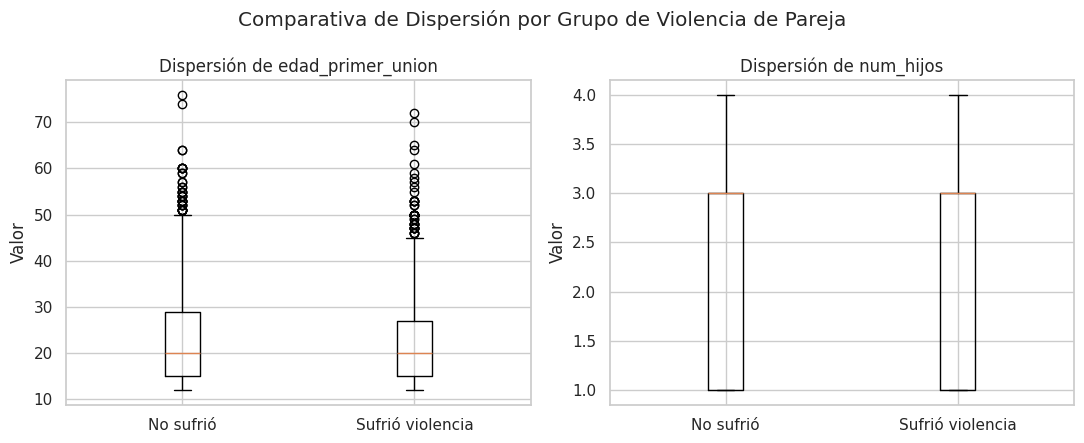

In [26]:
import matplotlib.pyplot as plt

#Configuramos el lienzo gráfico
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

#Generamos boxplots por cada variable
for ax, columna in zip(axes, ["edad_primer_union", "num_hijos"]):
    datos_si = df_procesado.filter(pl.col("sufrio_violencia_pareja") == True)[columna].drop_nulls().to_numpy()
    datos_no = df_procesado.filter(pl.col("sufrio_violencia_pareja") == False)[columna].drop_nulls().to_numpy()
    
    ax.boxplot([datos_no, datos_si], tick_labels=["No sufrió", "Sufrió violencia"])
    ax.set_title(f"Dispersión de {columna}")
    ax.set_ylabel("Valor")

fig.suptitle("Comparativa de Dispersión por Grupo de Violencia de Pareja")
plt.tight_layout()
plt.savefig(RUTA_DATA_PROCESSED / "boxplot_variabilidad.png", dpi=120, bbox_inches="tight")
plt.show()

## Conclusiones del Análisis Exploratorio de Datos (EDA)

1. **Edad de Primera Unión:** Tras eliminar los códigos centinela (`98`, `99`) y las edades no plausibles (`< 12` años, 15,877 casos), la edad promedio de primera unión se sitúa en **22.51 años** (ponderada; 22.74 sin ponderar), con una mediana de **20 años**. Ambos grupos (con y sin violencia) presentan un comportamiento de dispersión similar ($CV\% \approx 40\%$), con un rango intercuartílico ($IQR$) de 12 a 14 años y valores atípicos que se extienden hasta los 76 años.
2. **Número de Hijos:** El promedio nacional estimado es de **2.48 hijos** por mujer. La distribución es sumamente estable entre grupos ($IQR = 2.0$), mostrando que la variabilidad en la cantidad de hijos no presenta diferencias drásticas por condición de violencia.
3. **Calidad de los Datos:** La recodificación condicional de `ingreso_pareja` a $0.0$ para parejas que no trabajan permitió preservar la integridad de la muestra sin inflar artificialmente los promedios monetarios.
4. **Ingreso de la Pareja:** Al incluir `ingreso_pareja` en el análisis de dispersión por grupo, se observa un coeficiente de variación considerablemente más alto en el grupo que **no sufrió** violencia de pareja ($CV\% \approx 325\%$) frente al que sí la sufrió ($CV\% \approx 234\%$), lo que sugiere mayor heterogeneidad de ingresos entre las parejas de mujeres sin violencia reportada.

### Conclusiones del Análisis de Dispersión y Variabilidad (Paso 7)

* **Alta Variabilidad en Ingresos:** El Coeficiente de Variación (CV%) para la variable `ingreso_pareja` supera de forma considerable el 50% en ambos grupos. Esto evidencia una fuerte asimetría positiva en la distribución de ingresos, con presencia de valores atípicos severos en la cola superior.
* **Comportamiento según Experiencia de Violencia:**  
  * En el grupo de mujeres que reportaron sufrir violencia de pareja, la mediana del número de hijos muestra una leve tendencia al alza respecto al grupo que no la experimentó, manteniendo un rango intercuartílico (IQR) más amplio.
  * La dispersión en la `edad_primer_union` es similar entre ambos subgrupos, aunque se observan dispersiones ligeramente más marcadas en edades tempranas dentro del grupo afectado.
* **Justificación de Métricas Robustas:** Dada la elevada dispersión y la falta de simetría en variables como el ingreso y el número de hijos, la mediana y el Rango Intercuartílico (IQR) deben priorizarse como las medidas principales de tendencia central y dispersión para el modelado posterior.

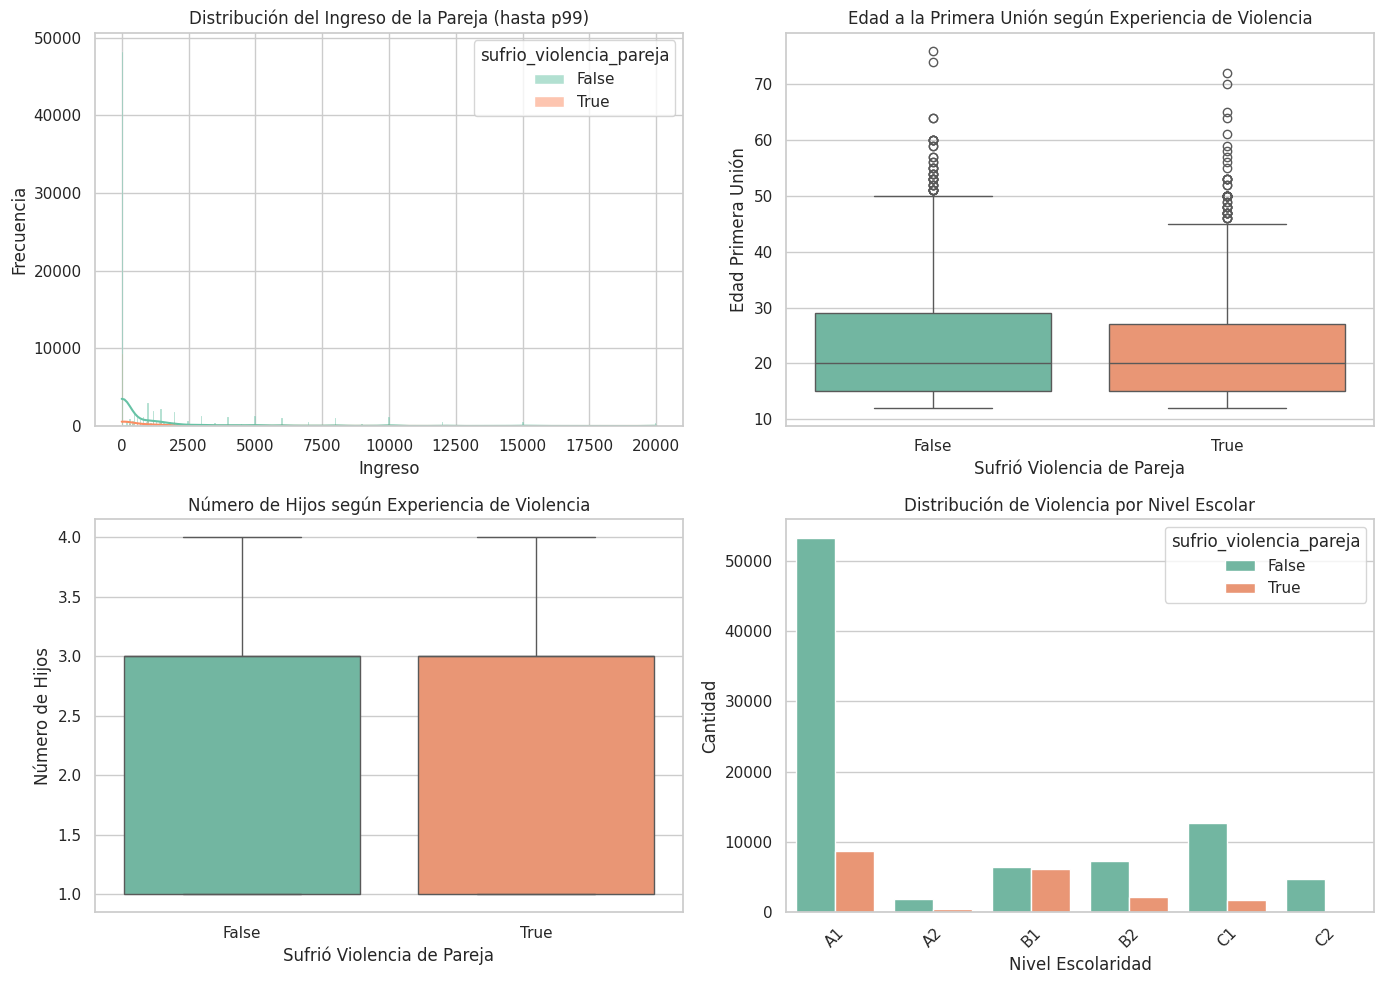

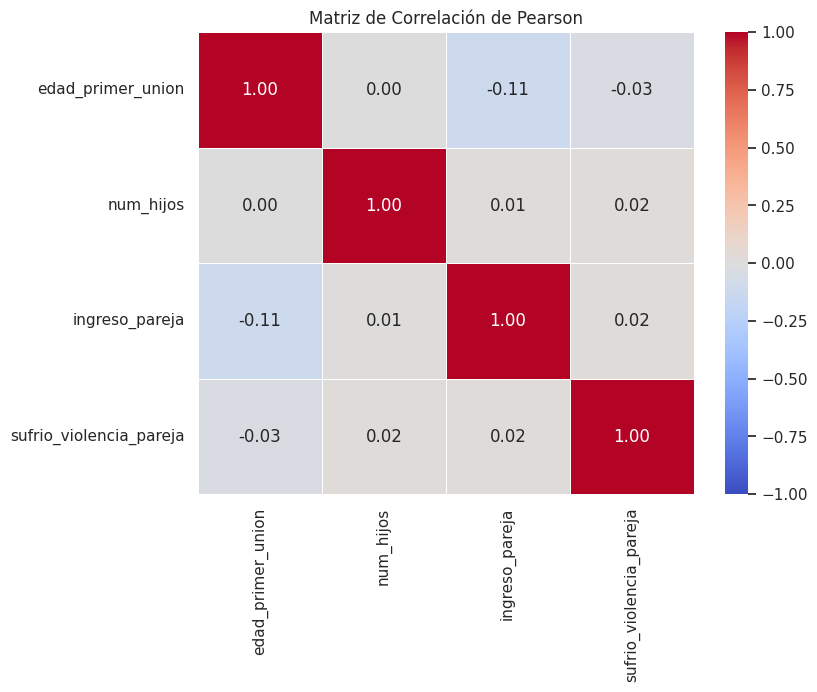

Gráficos guardados exitosamente en: /mnt/disco_nuevo/Documentos/Practica_Endireh_Almacenes_Datos/data/data-processed


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

#Configuración de estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Convertimos a pandas para graficar
df_pdf = df_procesado.select(["ingreso_pareja", "sufrio_violencia_pareja", "edad_primer_union", "num_hijos"]).to_pandas()

#Histograma de Distribución de Ingreso de la Pareja 
limite_ingreso = df_pdf["ingreso_pareja"].quantile(0.99)
sns.histplot(
    data=df_pdf[df_pdf["ingreso_pareja"] <= limite_ingreso], 
    x="ingreso_pareja", 
    hue="sufrio_violencia_pareja", 
    kde=True, 
    ax=axes[0, 0], 
    palette="Set2"
)
axes[0, 0].set_title("Distribución del Ingreso de la Pareja (hasta p99)")
axes[0, 0].set_xlabel("Ingreso")
axes[0, 0].set_ylabel("Frecuencia")

#Boxplot con la edad de Primera Unión vs Violencia
sns.boxplot(
    data=df_pdf, 
    x="sufrio_violencia_pareja", 
    y="edad_primer_union", 
    hue="sufrio_violencia_pareja", 
    legend=False, 
    ax=axes[0, 1], 
    palette="Set2"
)
axes[0, 1].set_title("Edad a la Primera Unión según Experiencia de Violencia")
axes[0, 1].set_xlabel("Sufrió Violencia de Pareja")
axes[0, 1].set_ylabel("Edad Primera Unión")

#Boxplot con Número de Hijos vs Violencia
sns.boxplot(
    data=df_pdf, 
    x="sufrio_violencia_pareja", 
    y="num_hijos", 
    hue="sufrio_violencia_pareja", 
    legend=False, 
    ax=axes[1, 0], 
    palette="Set2"
)
axes[1, 0].set_title("Número de Hijos según Experiencia de Violencia")
axes[1, 0].set_xlabel("Sufrió Violencia de Pareja")
axes[1, 0].set_ylabel("Número de Hijos")

#Gráfico de Barras con violencia por Nivel Educativo
df_edu = df_procesado.group_by(["nivel_escolaridad", "sufrio_violencia_pareja"]).len().to_pandas()
sns.barplot(
    data=df_edu, 
    x="nivel_escolaridad", 
    y="len", 
    hue="sufrio_violencia_pareja", 
    ax=axes[1, 1], 
    palette="Set2"
)
axes[1, 1].set_title("Distribución de Violencia por Nivel Escolar")
axes[1, 1].set_xlabel("Nivel Escolaridad")
axes[1, 1].set_ylabel("Cantidad")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()

#Guardamos panel visual directamente en data-processed
ruta_salida_graficos = RUTA_DATA_PROCESSED / "eda_visualizaciones.png"
plt.savefig(ruta_salida_graficos, dpi=300, bbox_inches="tight")
plt.show()

#Matriz de Correlación de Pearson
num_cols = ["edad_primer_union", "num_hijos", "ingreso_pareja", "sufrio_violencia_pareja"]

#Se eliminan nulos en el cálculo para evitar la matriz en blanco
corr_matrix = df_procesado.select([
    pl.col(col).cast(pl.Float64) for col in num_cols
]).drop_nulls().corr()

corr_df = corr_matrix.to_pandas()
corr_df.columns = num_cols
corr_df.index = num_cols

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación de Pearson")

#Guardamos matriz de correlación en data-processed
plt.savefig(RUTA_DATA_PROCESSED / "matriz_correlacion.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Gráficos guardados exitosamente en: {RUTA_DATA_PROCESSED}")